# Tree Species Image Classification

## 1. Dataset Exploration

This notebook explores the tree species dataset and develops image classification models using PyTorch and transfer learning.

In [ ]:
from pathlib import Path

# Dataset paths
data_dir = Path("archive")

train_dir = data_dir / "train"
val_dir = data_dir / "val"
test_dir = data_dir / "test"

print("Train:", train_dir.exists())
print("Validation:", val_dir.exists())
print("Test:", test_dir.exists())

In [7]:
from pathlib import Path

# Dataset paths
data_dir = Path("archive") / "tree"

train_dir = data_dir / "train"
val_dir = data_dir / "val"
test_dir = data_dir / "test"

print("Train:", train_dir.exists())
print("Validation:", val_dir.exists())
print("Test:", test_dir.exists())

Train: True
Validation: True
Test: True


In [8]:
# Get class names from the training folder
class_names = sorted([folder.name for folder in train_dir.iterdir() if folder.is_dir()])

print("Number of classes:", len(class_names))
print("\nClass names:")

for name in class_names:
    print(name)

Number of classes: 23

Class names:
Acer palmatum
Cedrus deodara
Celtis sinensis
Cinnamomum camphora (Linn) Presl
Elaeocarpus decipiens
Flowering cherry
Ginkgo biloba
Koelreuteria paniculata
Lagerstroemia indica
Liquidambar formosana
Liriodendron chinense
Magnolia grandiflora L
Magnolia liliflora Desr
Michelia chapensis
Osmanthus fragrans
Photinia serratifolia
Platanus
Prunus cerasifera f. atropurpurea
Salix babylonica
Sapindus saponaria
Styphnolobium japonicum
Triadica sebifera
Zelkova serrata


In [4]:
from pathlib import Path

print("Notebook working directory:")
print(Path.cwd())

print("\nFolders/files here:")
for item in Path.cwd().iterdir():
    print(item.name)

Notebook working directory:
c:\Users\mohsi\OneDrive\Desktop\Tree-Species-Project

Folders/files here:
.git
.gitignore
archive
negar_tree_project.ipynb
Notebook_7_–_Rock–Paper–Scissors_CNN.ipynb
README.md


In [5]:
from pathlib import Path

data_dir = Path("archive")

print("Inside archive:")
for item in data_dir.iterdir():
    print(item.name)

Inside archive:
tree


In [6]:
from pathlib import Path

tree_dir = Path("archive") / "tree"

print("Inside tree:")
for item in tree_dir.iterdir():
    print(item.name)

Inside tree:
test
train
val


In [9]:
def count_images(folder):
    return sum(1 for file in folder.rglob("*") if file.is_file())

print("Number of images per class:\n")

for class_name in class_names:
    train_count = count_images(train_dir / class_name)
    val_count = count_images(val_dir / class_name)
    test_count = count_images(test_dir / class_name)

    print(
        f"{class_name}: "
        f"Train={train_count}, "
        f"Val={val_count}, "
        f"Test={test_count}"
    )

Number of images per class:

Acer palmatum: Train=162, Val=21, Test=20
Cedrus deodara: Train=125, Val=16, Test=15
Celtis sinensis: Train=188, Val=24, Test=23
Cinnamomum camphora (Linn) Presl: Train=234, Val=29, Test=29
Elaeocarpus decipiens: Train=172, Val=23, Test=21
Flowering cherry: Train=106, Val=13, Test=13
Ginkgo biloba: Train=228, Val=28, Test=28
Koelreuteria paniculata: Train=223, Val=28, Test=28
Lagerstroemia indica: Train=65, Val=8, Test=8
Liquidambar formosana: Train=168, Val=21, Test=20
Liriodendron chinense: Train=182, Val=23, Test=22
Magnolia grandiflora L: Train=212, Val=26, Test=26
Magnolia liliflora Desr: Train=190, Val=24, Test=23
Michelia chapensis: Train=154, Val=19, Test=19
Osmanthus fragrans: Train=173, Val=22, Test=21
Photinia serratifolia: Train=120, Val=15, Test=15
Platanus: Train=193, Val=24, Test=24
Prunus cerasifera f. atropurpurea: Train=99, Val=12, Test=12
Salix babylonica: Train=136, Val=17, Test=16
Sapindus saponaria: Train=224, Val=28, Test=28
Styphnolo

### Dataset Distribution

The dataset contains 23 tree species classes and is already divided into training, validation, and test sets.

The number of images is not equal across all classes. Some classes contain more training images, while others contain considerably fewer images. For example, Cinnamomum camphora has 234 training images, whereas Lagerstroemia indica has only 65 training images.

Therefore, the dataset is imbalanced. This class imbalance may affect the classification performance, especially for classes with fewer training examples. The effect of this imbalance will be examined later when evaluating the models and their confusion matrices.

## 2. Visualizing Sample Images

In this section, sample images from different tree species are visualized to better understand the dataset and identify possible preprocessing requirements.

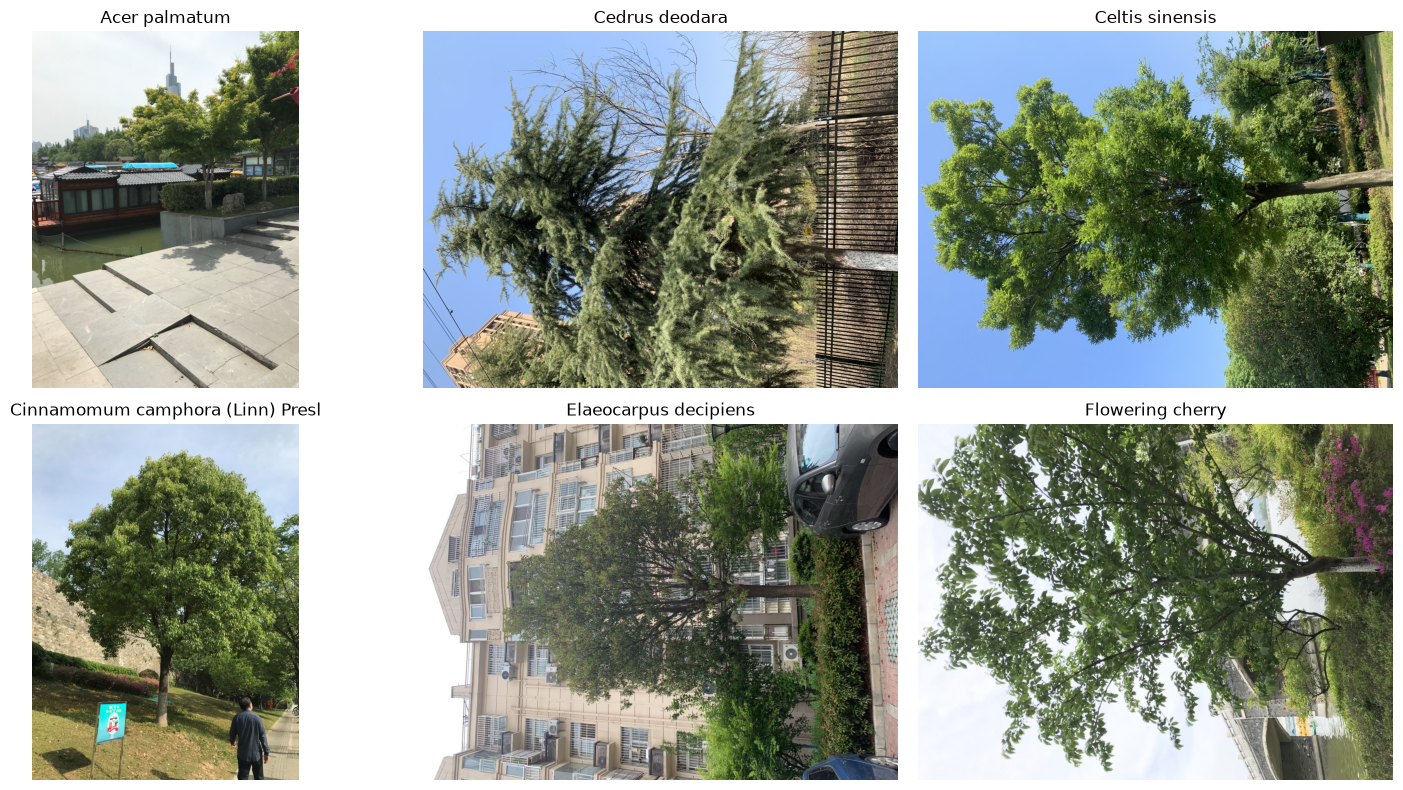

In [10]:
import matplotlib.pyplot as plt
from PIL import Image

# Show one sample image from the first 6 classes
plt.figure(figsize=(15, 8))

for i, class_name in enumerate(class_names[:6]):
    class_folder = train_dir / class_name
    image_path = next(class_folder.glob("*"))

    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()